# L09 · Convolutional Neural Networks for Blood-Cell Images

*Companion notebook for Lecture 9 — Convolutional Neural Networks (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Load and explore a biomedical image dataset stored as tensors of shape $C \times H \times W$.
2. Compute convolution output sizes $H_{out} = \lfloor (H + 2P - F)/S \rfloor + 1$ and parameter counts $(F\cdot F\cdot C_{in} + 1)\cdot C_{out}$, and check them against PyTorch.
3. Train a small CNN and an MLP with the **same parameter budget** on the same data, and compare them fairly.
4. Evaluate with accuracy, macro-F1 and a confusion matrix; test robustness to shifted images.
5. Look inside the CNN: first-layer filters and feature maps.
6. (Optional) Fine-tune an ImageNet-pretrained ResNet-18 (transfer learning).

Runtime: about 5 minutes on an Apple-silicon laptop (MPS) including the optional transfer-learning section; on a CPU (4 threads) the transfer-learning section is skipped and the whole notebook takes about 2.5–3 minutes (the CNN about 2 minutes). About 1 minute on a CUDA GPU including transfer learning (the executed copy of this notebook ran on an NVIDIA L40). The device (CUDA > MPS > CPU) is picked automatically.

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from medmnist import BloodMNIST, INFO
from course_utils import seed_everything, plot_style, device, DATA

rng = seed_everything(0)
plot_style()
dev = device()
torch.set_num_threads(max(1, torch.get_num_threads()))
print("device:", dev)

EPOCHS = 15          # 15 epochs: ~1.5 min for the CNN on a laptop CPU, ~1 min on MPS/GPU
BATCH = 128
RUN_TRANSFER = dev.type != "cpu"   # the optional ResNet-18 section is skipped automatically on CPU (too slow)

device: cuda


## 1. Dataset: white blood cells in peripheral blood smears

**Biological question.** Which type of blood cell is in this image? Counting the different white blood cell (leukocyte) types — the *differential count* — is part of the routine complete blood count. Shifts in the mix point to infection, allergy or parasites, and blood cancers; automated analyzers pre-classify cell images to speed up review.

- **What is measured:** a drop of peripheral blood is smeared on a glass slide, stained (May Grünwald–Giemsa), and each cell is imaged by an automated microscope (CellaVision DM96).
- **One sample** = one image of one cell, $\mathbf X \in \mathbb R^{3\times 28\times 28}$.
- **Target:** one of 8 classes — basophil, eosinophil, erythroblast, immature granulocytes (promyelocytes, myelocytes, metamyelocytes), lymphocyte, monocyte, neutrophil, platelet.

**Source.** BloodMNIST from *MedMNIST v2* (Yang et al., *Scientific Data* 10, 41, 2023; license CC BY 4.0). It is built from the dataset of Acevedo et al., *A dataset of microscopic peripheral blood cell images for development of automatic recognition systems*, *Data in Brief* 30, 105474 (2020): 17,092 images of normal cells (Hospital Clinic of Barcelona, individuals without infection, hematologic or oncologic disease), 360 × 363 px, center-cropped and resized to 28 × 28 by MedMNIST. We use the official train/validation/test split. The files (35 MB) are cached in `applications/data/`.

In [2]:
splits = {s: BloodMNIST(split=s, download=True, root=str(DATA)) for s in ["train", "val", "test"]}
CLASSES = ["basophil", "eosinophil", "erythroblast", "immature gran.", "lymphocyte", "monocyte", "neutrophil", "platelet"]

def to_tensors(ds):
    x = torch.tensor(ds.imgs).permute(0, 3, 1, 2).float() / 255   # N x H x W x C  ->  N x C x H x W
    y = torch.tensor(ds.labels[:, 0]).long()
    return x, y

X_tr, y_tr = to_tensors(splits["train"])
X_va, y_va = to_tensors(splits["val"])
X_te, y_te = to_tensors(splits["test"])
print("train", tuple(X_tr.shape), " val", tuple(X_va.shape), " test", tuple(X_te.shape))
print("pixel range:", X_tr.min().item(), "to", X_tr.max().item())

train (11959, 3, 28, 28)  val (1712, 3, 28, 28)  test (3421, 3, 28, 28)
pixel range: 0.0 to 1.0


## 2. Exploration: class balance and example cells

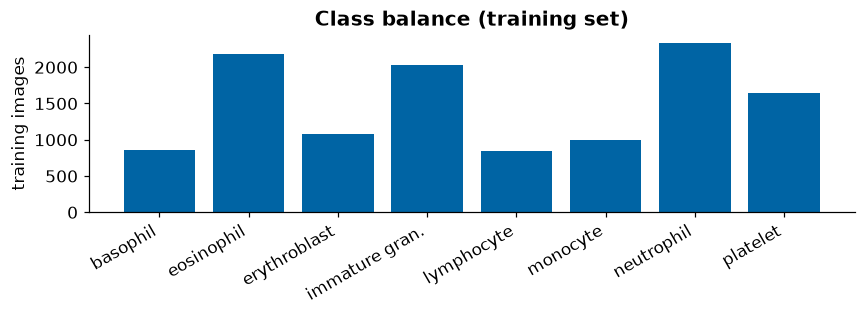

basophil          852  (7.1%)
eosinophil       2181  (18.2%)
erythroblast     1085  (9.1%)
immature gran.   2026  (16.9%)
lymphocyte        849  (7.1%)
monocyte          993  (8.3%)
neutrophil       2330  (19.5%)
platelet         1643  (13.7%)


In [3]:
counts = np.bincount(y_tr.numpy(), minlength=8)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(CLASSES, counts)
ax.set(ylabel="training images", title="Class balance (training set)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
for c, n in zip(CLASSES, counts):
    print(f"{c:15s} {n:5d}  ({100 * n / counts.sum():.1f}%)")

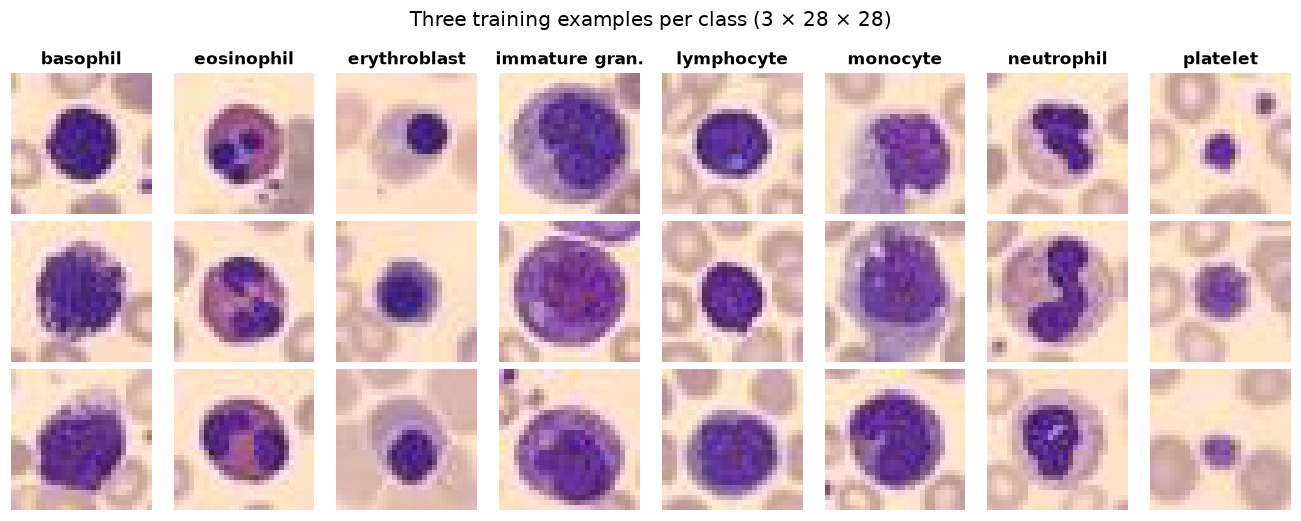

In [4]:
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for c in range(8):
    idx = np.where(y_tr.numpy() == c)[0][:3]
    for r, i in enumerate(idx):
        axes[r, c].imshow(X_tr[i].permute(1, 2, 0))
        axes[r, c].axis("off")
    axes[0, c].set_title(CLASSES[c], fontsize=11)
plt.suptitle("Three training examples per class (3 × 28 × 28)"); plt.tight_layout(); plt.show()

The classes are imbalanced (neutrophils and eosinophils are common, basophils and lymphocytes rarer), so besides accuracy we report **macro-F1** (the unweighted mean of per-class F1 scores). At 28 × 28 pixels, much of the chromatin texture and granularity a hematologist uses is gone — keep this in mind when reading the errors.

## 3. Preprocessing
Standardize each channel with the **training-set** mean and standard deviation (never with validation/test statistics).

In [5]:
mu = X_tr.mean(dim=(0, 2, 3), keepdim=True)
sd = X_tr.std(dim=(0, 2, 3), keepdim=True)
norm = lambda x: (x - mu) / sd
print("channel means:", mu.flatten().numpy().round(3), " SDs:", sd.flatten().numpy().round(3))

channel means: [0.794 0.66  0.696]  SDs: [0.216 0.242 0.118]


## 4. Convolution arithmetic, checked in code
The lecture's worked example: input $3\times 32\times 32$, ten $5\times 5$ filters, stride 1, padding 2.

In [6]:
def out_size(H, F, S, P):
    return (H + 2 * P - F) // S + 1

def conv_params(F, c_in, c_out):
    return (F * F * c_in + 1) * c_out

conv = nn.Conv2d(3, 10, kernel_size=5, stride=1, padding=2)
print("formula:  output", (10, out_size(32, 5, 1, 2), out_size(32, 5, 1, 2)), " params", conv_params(5, 3, 10))
print("PyTorch:  output", tuple(conv(torch.zeros(1, 3, 32, 32)).shape[1:]),
      " params", sum(p.numel() for p in conv.parameters()))
print("checkpoint: 3x3 conv, 64 -> 128 channels:", conv_params(3, 64, 128), "parameters")

formula:  output (10, 32, 32)  params 760
PyTorch:  output (10, 32, 32)  params 760
checkpoint: 3x3 conv, 64 -> 128 channels: 73856 parameters


## 5. Two models with the same parameter budget

- **CNN**: three convolution blocks (32, 64, 128 filters) with BatchNorm, ReLU and max-pooling, then **global average pooling** and a linear layer.
- **MLP** (the L08 baseline): flatten the image to $\mathbf x\in\mathbb R^{2352}$, two hidden layers of 40 units.

The widths were chosen so both have about 96 thousand parameters — any difference in performance comes from the architecture (the *inductive bias*), not from size.

In [7]:
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),     # 32 x 14 x 14
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),    # 64 x 7 x 7
        nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),                   # 128 x 7 x 7
        nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 8))

def make_mlp():
    return nn.Sequential(nn.Flatten(), nn.Linear(3 * 28 * 28, 40), nn.BatchNorm1d(40), nn.ReLU(),
                         nn.Linear(40, 40), nn.BatchNorm1d(40), nn.ReLU(), nn.Linear(40, 8))

n_params = lambda m: sum(p.numel() for p in m.parameters())
print("CNN parameters:", f"{n_params(make_cnn()):,}")
print("MLP parameters:", f"{n_params(make_mlp()):,}")

# trace the tensor shapes through the CNN
x = torch.zeros(1, 3, 28, 28)
for layer in make_cnn().eval():
    x = layer(x)
    if not isinstance(layer, (nn.ReLU, nn.BatchNorm2d)):
        print(f"{layer.__class__.__name__:18s} -> {tuple(x.shape[1:])}")

CNN parameters: 96,264
MLP parameters: 96,248
Conv2d             -> (32, 28, 28)
MaxPool2d          -> (32, 14, 14)
Conv2d             -> (64, 14, 14)
MaxPool2d          -> (64, 7, 7)
Conv2d             -> (128, 7, 7)
AdaptiveAvgPool2d  -> (128, 1, 1)
Flatten            -> (128,)
Linear             -> (8,)


## 6. Training
Identical recipe for both models: Adam with a one-cycle learning-rate schedule, cross-entropy loss, mini-batches of 128, and model selection on the **validation** set (best epoch). The test set is used once, at the end.

In [8]:
def predict(model, X, bs=1000):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out.append(torch.softmax(model(norm(X[i:i + bs]).to(dev)), 1).cpu())
    return torch.cat(out)

def train(make, epochs=EPOCHS, augment=False, seed=0, X=X_tr, y=y_tr):
    torch.manual_seed(seed)
    g = np.random.default_rng(seed)
    model = make().to(dev)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    steps = int(np.ceil(len(X) / BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, total_steps=epochs * steps)
    hist = {"train_loss": [], "train_acc": [], "val_acc": []}
    best, best_state = -1, None
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        tot, correct = 0.0, 0
        for i in range(0, len(X), BATCH):
            idx = perm[i:i + BATCH]
            xb, yb = norm(X[idx]).to(dev), y[idx].to(dev)
            if augment:  # cells have no canonical orientation
                xb = torch.rot90(xb, int(g.integers(4)), (2, 3))
                if g.random() < 0.5:
                    xb = xb.flip(3)
            opt.zero_grad()
            logits = model(xb)
            loss = nn.functional.cross_entropy(logits, yb)
            loss.backward()
            opt.step(); sched.step()
            tot += loss.item() * len(idx)
            correct += (logits.argmax(1) == yb).sum().item()
        va = (predict(model, X_va).argmax(1) == y_va).float().mean().item()
        hist["train_loss"].append(tot / len(X)); hist["train_acc"].append(correct / len(X)); hist["val_acc"].append(va)
        if va > best:
            best, best_state = va, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, hist

results = {}
for name, make in [("MLP", make_mlp), ("CNN", make_cnn)]:
    t0 = time.time()
    model, hist = train(make)
    results[name] = {"model": model, "hist": hist}
    print(f"{name}: {time.time() - t0:.0f}s  final train acc {hist['train_acc'][-1]:.3f}  "
          f"best val acc {max(hist['val_acc']):.3f} (epoch {int(np.argmax(hist['val_acc'])) + 1})")

MLP: 6s  final train acc 0.984  best val acc 0.877 (epoch 15)


CNN: 13s  final train acc 0.982  best val acc 0.953 (epoch 13)


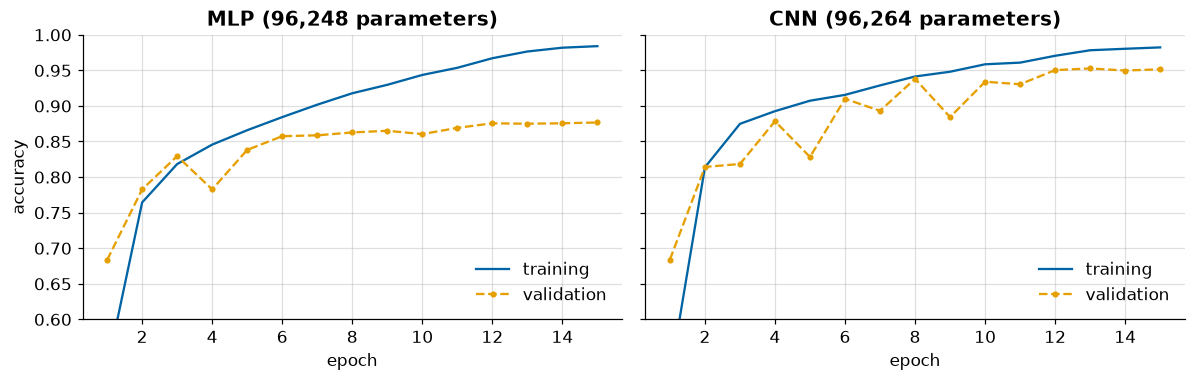

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, name in zip(axes, results):
    h = results[name]["hist"]
    ep = np.arange(1, EPOCHS + 1)
    ax.plot(ep, h["train_acc"], label="training"); ax.plot(ep, h["val_acc"], "--o", ms=3, label="validation")
    ax.set(title=f"{name} ({n_params(results[name]['model']):,} parameters)", xlabel="epoch", ylim=(0.6, 1.0))
    ax.grid(alpha=0.4); ax.legend(loc="lower right")
axes[0].set_ylabel("accuracy"); plt.tight_layout(); plt.show()

Both models reach high *training* accuracy, but the MLP's validation accuracy plateaus far below it: with the same number of parameters it memorizes pixel patterns at fixed positions, while the CNN's shared local filters generalize.

## 7. Evaluation on the test set

In [10]:
for name in results:
    p = predict(results[name]["model"], X_te).argmax(1).numpy()
    results[name]["pred"] = p
    print(f"{name}: test accuracy {np.mean(p == y_te.numpy()):.3f}   macro-F1 {f1_score(y_te, p, average='macro'):.3f}")

print("\nCNN per-class report:")
print(classification_report(y_te, results["CNN"]["pred"], target_names=CLASSES, digits=3))

MLP: test accuracy 0.866   macro-F1 0.848
CNN: test accuracy 0.949   macro-F1 0.942

CNN per-class report:
                precision    recall  f1-score   support

      basophil      0.936     0.902     0.919       244
    eosinophil      0.995     0.986     0.990       624
  erythroblast      0.977     0.968     0.973       311
immature gran.      0.865     0.910     0.887       579
    lymphocyte      0.919     0.934     0.927       243
      monocyte      0.906     0.849     0.876       284
    neutrophil      0.966     0.968     0.967       666
      platelet      1.000     1.000     1.000       470

      accuracy                          0.949      3421
     macro avg      0.946     0.940     0.942      3421
  weighted avg      0.949     0.949     0.949      3421



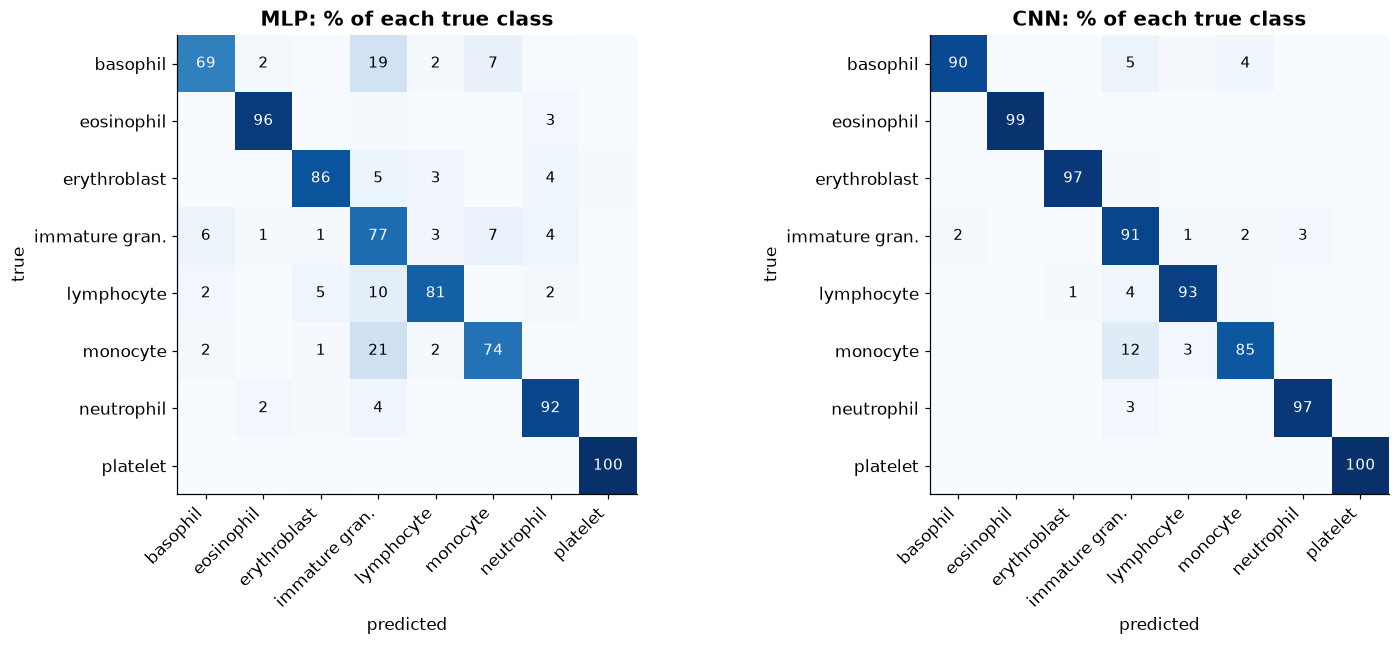

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, results):
    cm = confusion_matrix(y_te, results[name]["pred"], labels=range(8))
    cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(8):
        for j in range(8):
            if cmn[i, j] >= 0.01:
                ax.text(j, i, f"{100 * cmn[i, j]:.0f}", ha="center", va="center", fontsize=10,
                        color="white" if cmn[i, j] > 0.6 else "black")
    ax.set_xticks(range(8), CLASSES, rotation=45, ha="right", fontsize=11)
    ax.set_yticks(range(8), CLASSES, fontsize=11)
    ax.set(title=f"{name}: % of each true class", xlabel="predicted", ylabel="true")
plt.tight_layout(); plt.show()

## 8. Robustness to shifted cells
The acquisition device centers each cell. What happens if we shift the test images by a few pixels (circularly, down and right)? Convolutions are translation **equivariant**, and global average pooling turns that into approximate **invariance** of the prediction. The MLP has no such structure.

MLP accuracy vs shift: [0.866 0.806 0.682 0.549 0.45  0.378 0.316]


CNN accuracy vs shift: [0.949 0.933 0.901 0.855 0.827 0.767 0.723]


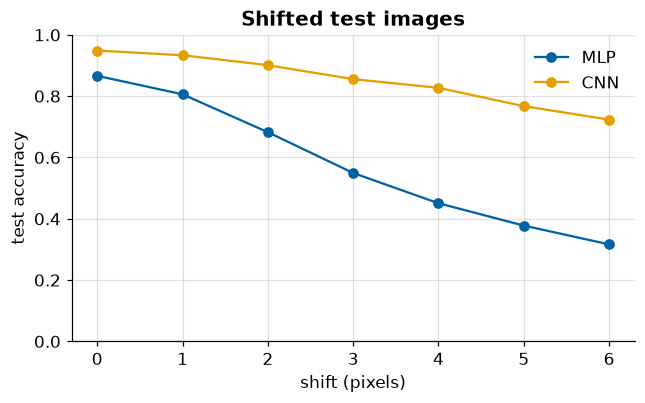

In [12]:
shifts = range(0, 7)
fig, ax = plt.subplots(figsize=(6, 3.8))
for name in results:
    accs = [(predict(results[name]["model"], torch.roll(X_te, (s, s), (2, 3))).argmax(1) == y_te).float().mean().item()
            for s in shifts]
    ax.plot(list(shifts), accs, "o-", label=name)
    print(name, "accuracy vs shift:", np.round(accs, 3))
ax.set(xlabel="shift (pixels)", ylabel="test accuracy", ylim=(0, 1), title="Shifted test images")
ax.legend(); ax.grid(alpha=0.4); plt.tight_layout(); plt.show()

**Numbers vs the lecture slides.** The slides were produced on an Apple-silicon GPU (MPS): MLP 86.7% / macro-F1 0.848,
CNN 95.1% / 0.945, and at a 4-px shift CNN 81.5% vs MLP 44.2%. With the same code, data and seeds, a 4-thread CPU run
gave MLP 86.5% / 0.847, CNN 95.2% / 0.946, and at 4 px CNN 83.5% vs MLP 44.0%; the executed copy (NVIDIA L40 GPU) gave
MLP 86.6% / 0.848, CNN 94.9% / 0.942, at 4 px CNN 82.7% vs MLP 45.0%, and ResNet-18 81.4% frozen / 93.5% fine-tuned
(slides 81.3% / 93.7%). Floating-point arithmetic differs
between devices, so the training trajectories diverge slightly; differences of a few tenths of a point (up to about
2 points on the shifted images) are smaller than the spread you would see across random seeds. The conclusions do not change.


## 9. Inside the CNN: filters and feature maps

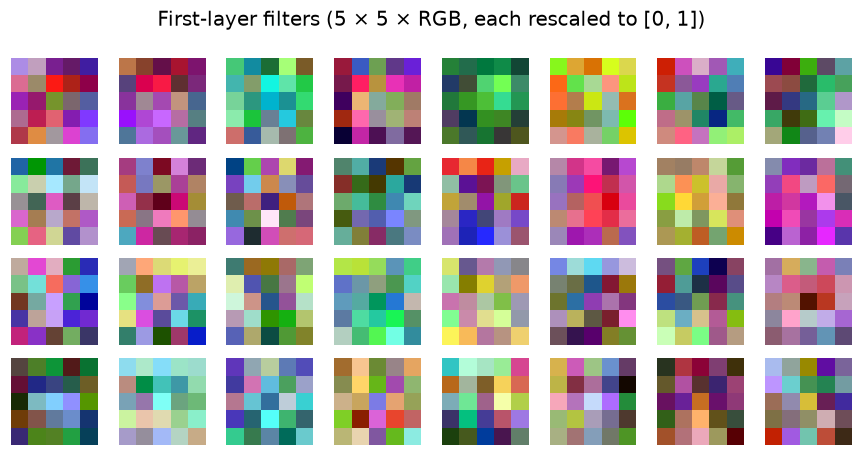

In [13]:
cnn = results["CNN"]["model"].cpu().eval()
W = cnn[0].weight.detach()            # 32 x 3 x 5 x 5
fig, axes = plt.subplots(4, 8, figsize=(8, 4.2))
for k, ax in enumerate(axes.ravel()):
    w = W[k].permute(1, 2, 0).numpy()
    ax.imshow((w - w.min()) / (w.max() - w.min() + 1e-9)); ax.axis("off")
plt.suptitle("First-layer filters (5 × 5 × RGB, each rescaled to [0, 1])"); plt.tight_layout(); plt.show()

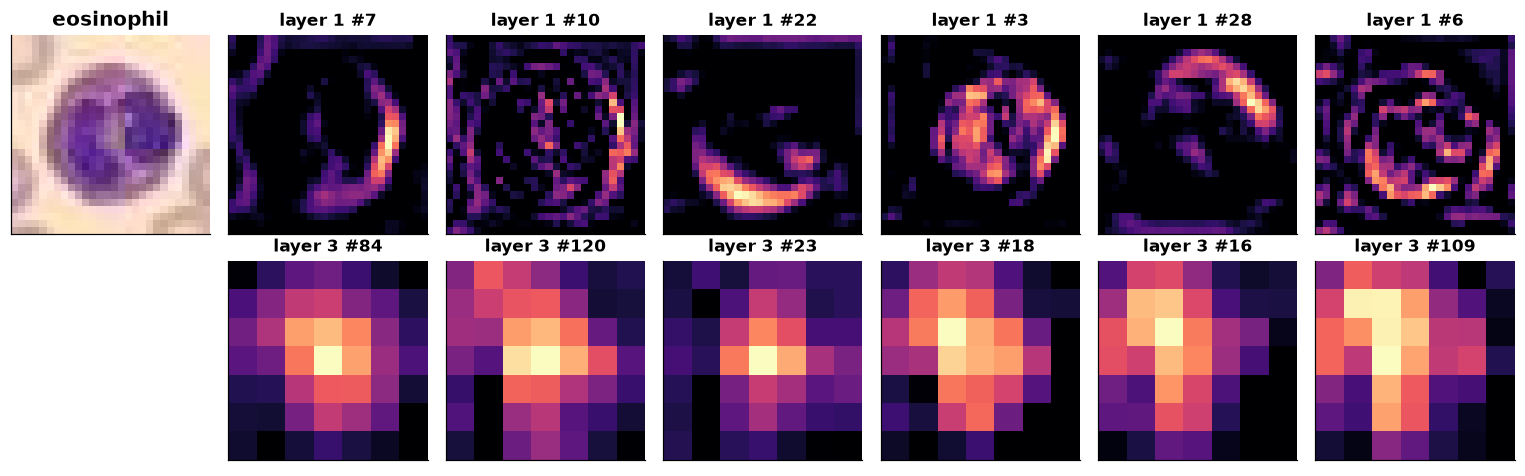

In [14]:
i = int(np.where(y_te.numpy() == 1)[0][0])       # the first eosinophil in the test set
x = norm(X_te[i:i + 1])
with torch.no_grad():
    a1 = cnn[:3](x)[0]     # after conv1 + BN + ReLU: 32 x 28 x 28
    a3 = cnn[:11](x)[0]    # after conv3 + BN + ReLU: 128 x 7 x 7
fig, axes = plt.subplots(2, 7, figsize=(14, 4.4))
axes[0, 0].imshow(X_te[i].permute(1, 2, 0)); axes[0, 0].set_title(CLASSES[int(y_te[i])])
axes[1, 0].axis("off")
for r, A in enumerate([a1, a3]):
    top = torch.argsort(A.std((1, 2)), descending=True)[:6]
    for c, k in enumerate(top):
        axes[r, c + 1].imshow(A[k], cmap="magma"); axes[r, c + 1].set_title(f"{'layer 1' if r == 0 else 'layer 3'} #{int(k)}", fontsize=11)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
_ = cnn.to(dev)

First-layer filters are small color-opponent blobs and edges (purple nucleus vs. pink background and granules). Layer-1 maps are 28 × 28 and outline the nucleus and membrane; layer-3 maps are coarse (7 × 7) and respond to larger parts of the cell. These pictures are suggestive, not proof of what the network relies on.

## 10. (Optional) Transfer learning with an ImageNet-pretrained ResNet-18
We replace the final layer of ResNet-18 with an 8-class head and compare **feature extraction** (train only the head) with **full fine-tuning**. Images are upsampled to 64 × 64 and normalized with ImageNet statistics. This section runs only when a GPU/MPS device is available (`RUN_TRANSFER`); on a CPU it would take tens of minutes. Pretrained weights (45 MB) are cached under `applications/data/torch`. The slides report 81.3% test accuracy for feature extraction and 93.7% for fine-tuning (Apple MPS); a CUDA GPU run of this cell gave 81.4% and 94.8% (about 25 s).

In [15]:
if RUN_TRANSFER:
    import os, torchvision
    os.environ["TORCH_HOME"] = str(DATA / "torch")
    im_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    im_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    prep = lambda x: nn.functional.interpolate((x - im_mean) / im_std, size=64, mode="bilinear", align_corners=False)
    for mode in ["feature extraction", "fine-tuning"]:
        torch.manual_seed(0)
        net = torchvision.models.resnet18()
        net.load_state_dict(torchvision.models.ResNet18_Weights.IMAGENET1K_V1.get_state_dict(progress=False))
        net.fc = nn.Linear(512, 8)
        if mode == "feature extraction":
            for n_, p in net.named_parameters():
                p.requires_grad = n_.startswith("fc.")
        net = net.to(dev)
        params = [p for p in net.parameters() if p.requires_grad]
        opt = torch.optim.Adam(params, lr=1e-3 if mode == "feature extraction" else 3e-4)
        t0 = time.time()
        for ep in range(3):
            net.train()
            if mode == "feature extraction":
                net.eval()          # keep the pretrained BatchNorm statistics fixed
            perm = torch.randperm(len(X_tr))
            for i in range(0, len(X_tr), 64):
                idx = perm[i:i + 64]
                opt.zero_grad()
                nn.functional.cross_entropy(net(prep(X_tr[idx]).to(dev)), y_tr[idx].to(dev)).backward()
                opt.step()
        net.eval()
        with torch.no_grad():
            pred = torch.cat([net(prep(X_te[i:i + 500]).to(dev)).argmax(1).cpu() for i in range(0, len(X_te), 500)])
        print(f"{mode:18s}: trainable params {sum(p.numel() for p in params):>10,}   "
              f"test accuracy {(pred == y_te).float().mean().item():.3f}   ({time.time() - t0:.0f}s)")
else:
    print("Skipped on CPU (set RUN_TRANSFER = True to run anyway; expect > 20 minutes).")

feature extraction: trainable params      4,104   test accuracy 0.814   (5s)


fine-tuning       : trainable params 11,180,616   test accuracy 0.935   (16s)


## 11. Biological interpretation

- With the **same number of parameters**, the CNN clearly beats the MLP on held-out cells, and it keeps working when cells are not perfectly centered. Locality and weight sharing are the right prior for microscopy.
- The remaining errors concentrate in biologically plausible places — e.g., monocytes vs. immature granulocytes (both large mononuclear-looking cells at 28 px) and the maturation continuum of granulocytes. Higher-resolution inputs (MedMNIST+ offers 64–224 px) and more careful labels would help more than a bigger network.
- These cells come from healthy donors at one hospital with one staining protocol and one analyzer. Performance on smears from other labs, stains, or patients with leukemia would have to be checked separately (domain shift — L10).

## Try it yourself

1. **Remove the pooling layers: parameters, speed, accuracy?** Delete the two `nn.MaxPool2d(2)` in `make_cnn` (keep stride 1 everywhere). Why does global average pooling keep the parameter count the same?
2. **Train on 10% of the data: which model suffers more?** Use `train(make_cnn, X=X_tr[:1200], y=y_tr[:1200])` and the same for `make_mlp`. (For reference, on a 4-thread CPU: CNN 86.9%, MLP 74.8% test accuracy.)
3. **Add rotations and flips: does the gap shrink?** Train the CNN with `train(make_cnn, augment=True)` (random 90° rotations and flips). Compare the final training accuracy with the best validation accuracy, and the accuracy on images shifted by 4 px. (The lecture reports 95.4% test accuracy for the CNN with augmentation; on a CPU we got 95.1%, training accuracy 95.7% vs 98.3% without augmentation.)
4. **Receptive field:** replace the 5 × 5 first layer by a 3 × 3 layer. Compute the receptive field of the last conv layer by hand, then compare accuracy.
5. **Class weights:** pass `weight=` to `cross_entropy` (inverse class frequency). What happens to macro-F1 versus accuracy?